<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/mini_batch_gradient_descent_with_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 미니배치 경사하강법 (Mini-batch Gradient Descent) 쉽게 이해하기

> **비전공자를 위한 친절한 입문 노트북 + 직접 코딩 실습 포함**

---

## 📚 오늘의 학습 목표

이 노트북을 끝내면 다음 질문에 답할 수 있게 됩니다.

1. **경사하강법**이 도대체 뭔가요? → 산에서 내려오는 비유로 이해해 봅니다
2. **배치, 미니배치, 확률적(SGD)** 경사하강법은 뭐가 다른가요?
3. **왜** 딥러닝에서는 거의 다 미니배치를 쓰는 걸까요?
4. **배치 크기(batch size)**를 바꾸면 학습이 어떻게 달라질까요?

## 🧭 이렇게 진행됩니다

| 단계 | 내용 |
|---|---|
| 1 | 비유로 이해하기 (산 내려오기) |
| 2 | 손실함수와 기울기를 그림으로 보기 |
| 3 | 세 가지 방식의 차이 한눈에 비교 |
| 4 | 미니배치란 무엇인가 (그림으로) |
| 5 | **✏️ 직접 코딩** — 손실함수, 기울기, 미니배치 GD |
| 6 | 배치 크기 바꿔가며 실험 |
| 7 | 정리 & 한 줄 요약 |

## 🛠️ 실습 코드 사용법

이 노트북에는 **3개의 빈칸 채우기 연습**이 있습니다.

- **✏️ 연습 셀**: 빈칸(`...`)을 채워서 함수를 완성합니다
- **🧪 자가 검증 셀**: 실행하면 정답인지 자동으로 알려줍니다
- **🔑 정답 보기**: 충분히 시도해본 뒤 펼쳐보세요

## 🔧 0. 환경 준비 (한글 폰트 설정)

In [1]:
# 한글 폰트 설치 (코랩 1회만 실행)
!apt-get -qq install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import numpy as np
np.random.seed(42)

print("✅ 환경 준비 완료!")

✅ 환경 준비 완료!


## 🏔️ 1. 경사하강법, 일단 비유부터!

### 상황: 안개 낀 산 정상에서 길을 잃었습니다

여러분은 지금 **안개가 자욱한 산 정상**에 있고, 빨리 산 아래로 내려가야 합니다.
GPS도 없고, 지도도 없고, 시야는 5미터뿐입니다.

> 💡 **현실적인 답**: 발로 주변을 살짝 디뎌보고, **가장 가파르게 내려가는 방향으로 한 걸음** 씁니다.

이게 바로 **경사하강법(Gradient Descent)** 입니다!

| 산 비유 | 머신러닝 용어 |
|---|---|
| 산의 높이 | 손실(Loss) — 모델이 얼마나 틀렸는지 |
| 골짜기 | 학습 완료 (모델이 잘 맞히는 상태) |
| 발로 디뎌서 경사 살피기 | 기울기(Gradient) 계산 |
| 한 걸음의 보폭 | 학습률(Learning rate) |

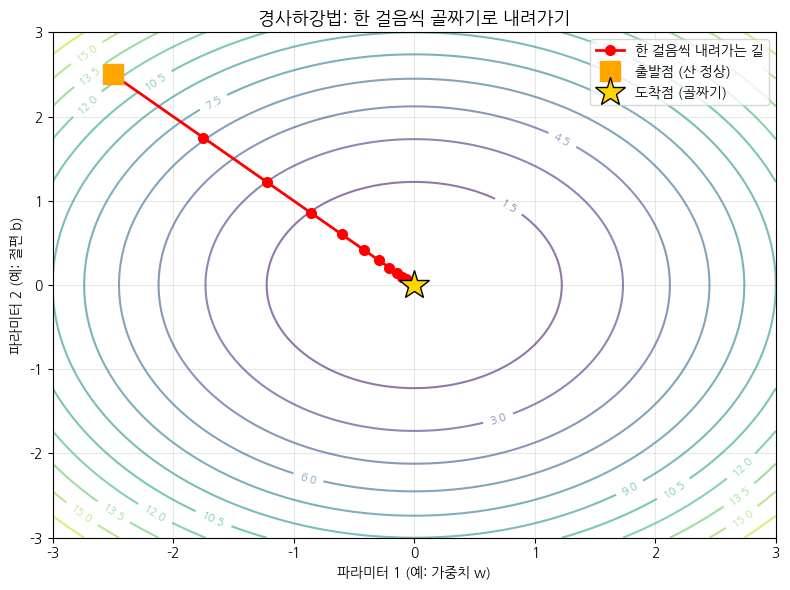

In [2]:
# 🎨 산에서 내려오는 모습을 등고선으로 그려봅시다
fig, ax = plt.subplots(figsize=(8, 6))

x = np.linspace(-3, 3, 100); y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y); Z = X**2 + Y**2

contour = ax.contour(X, Y, Z, levels=15, cmap='viridis', alpha=0.6)
ax.clabel(contour, inline=True, fontsize=8)

path = [(-2.5, 2.5)]; pos = np.array([-2.5, 2.5])
for _ in range(15):
    grad = 2 * pos
    pos = pos - 0.15 * grad
    path.append(tuple(pos))
px, py = zip(*path)
ax.plot(px, py, 'o-', color='red', markersize=7, linewidth=2, label='한 걸음씩 내려가는 길')
ax.plot(px[0], py[0], 's', color='orange', markersize=14, label='출발점 (산 정상)')
ax.plot(0, 0, '*', color='gold', markersize=22, markeredgecolor='black', label='도착점 (골짜기)')

ax.set_xlabel('파라미터 1 (예: 가중치 w)')
ax.set_ylabel('파라미터 2 (예: 절편 b)')
ax.set_title('경사하강법: 한 걸음씩 골짜기로 내려가기', fontsize=13)
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 👥 2. 핵심 질문: "기울기를 잴 때, 데이터를 몇 개 볼까?"

### 📦 학교 비유로 이해하기

> **상황**: 우리 학교 학생들의 평균 키를 빠르게 추정하고 싶습니다.

| 방식 | 학교 비유 | 머신러닝 이름 |
|---|---|---|
| 🐢 **전교생 다 측정** | 정확하지만 너무 느림 | **배치 경사하강법** (Batch GD) |
| 🐇 **딱 한 명만 측정** | 매우 빠르지만 들쭉날쭉 | **확률적 경사하강법** (SGD) |
| 🚲 **한 반 30명만 측정** | 적당히 빠르고 적당히 정확 ✨ | **미니배치 경사하강법** (Mini-batch GD) |

대부분의 딥러닝은 **🚲 미니배치** 방식을 씁니다.

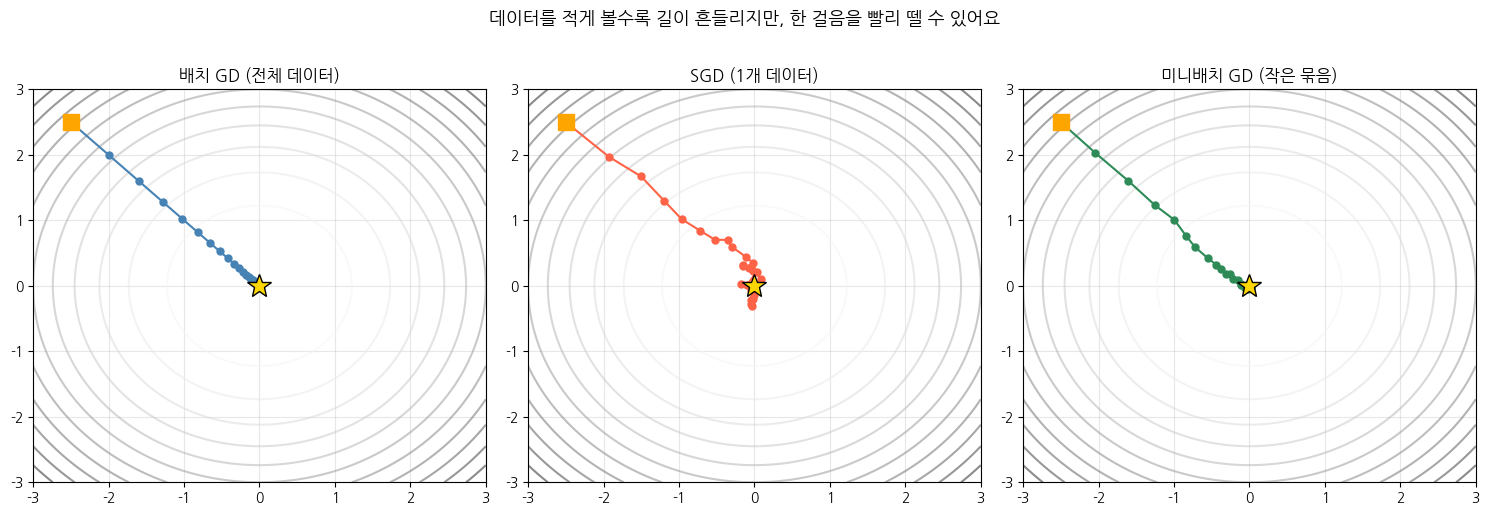

In [3]:
# 🎨 세 방식의 '한 걸음 내딛는 방향' 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['배치 GD (전체 데이터)', 'SGD (1개 데이터)', '미니배치 GD (작은 묶음)']
colors = ['steelblue', 'tomato', 'seagreen']

x = np.linspace(-3, 3, 100); y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y); Z = X**2 + Y**2

np.random.seed(0)
noise_levels = [0.0, 0.8, 0.25]

for ax, title, color, noise in zip(axes, titles, colors, noise_levels):
    contour = ax.contour(X, Y, Z, levels=12, cmap='Greys', alpha=0.5)
    pos = np.array([-2.5, 2.5]); path = [pos.copy()]
    for _ in range(25):
        grad = 2 * pos + np.random.randn(2) * noise
        pos = pos - 0.1 * grad
        path.append(pos.copy())
    px, py = zip(*path)
    ax.plot(px, py, 'o-', color=color, markersize=5, linewidth=1.5)
    ax.plot(px[0], py[0], 's', color='orange', markersize=12)
    ax.plot(0, 0, '*', color='gold', markersize=18, markeredgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.grid(alpha=0.3)

plt.suptitle('데이터를 적게 볼수록 길이 흔들리지만, 한 걸음을 빨리 뗄 수 있어요',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 📦 3. 미니배치란? — 그림으로 이해하기

전체 데이터를 작은 묶음(=미니배치)으로 나눠서, **묶음 단위로 한 걸음씩** 학습합니다.

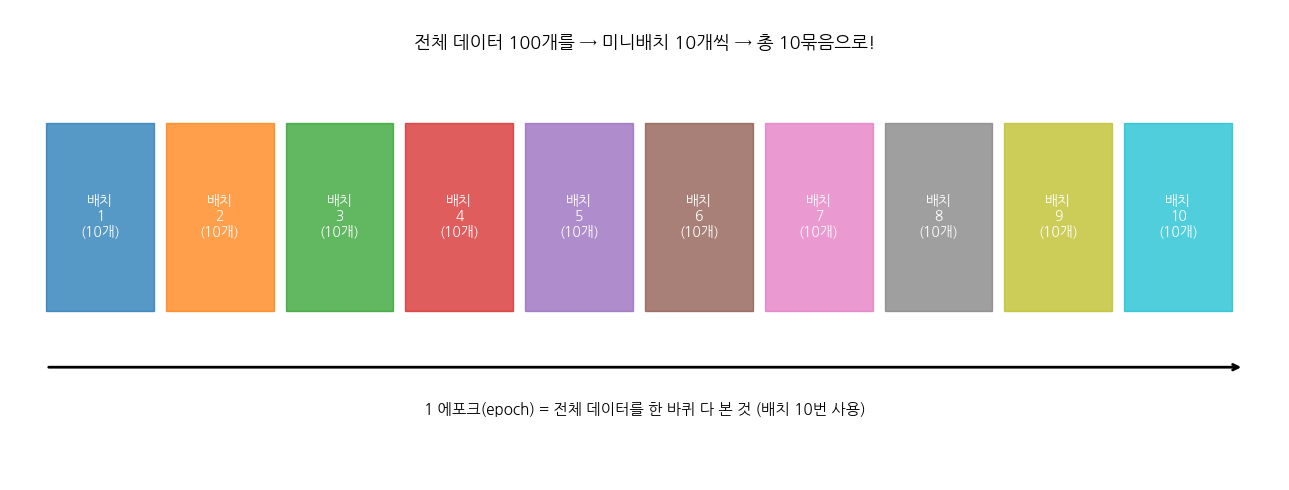

✅ 핵심 용어 정리
  • 배치 크기(batch size): 한 번에 보는 데이터 개수
  • 에포크(epoch): 전체 데이터를 처음부터 끝까지 한 번 다 사용한 것
  • 반복(iteration): 가중치 업데이트 1회


In [4]:
# 🎨 미니배치 개념도: 데이터 100개를 10개씩 나누기
fig, ax = plt.subplots(figsize=(13, 5))

total = 100; batch_size = 10; n_batches = total // batch_size
cmap = plt.cm.tab10
for i in range(n_batches):
    rect = plt.Rectangle((i * 1.0, 0), 0.9, 1, color=cmap(i), alpha=0.75)
    ax.add_patch(rect)
    ax.text(i * 1.0 + 0.45, 0.5, f'배치\n{i+1}\n({batch_size}개)',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.annotate('', xy=(10, -0.3), xytext=(0, -0.3),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(5, -0.55, '1 에포크(epoch) = 전체 데이터를 한 바퀴 다 본 것 (배치 10번 사용)',
        ha='center', fontsize=11, fontweight='bold')
ax.text(5, 1.4, '전체 데이터 100개를 → 미니배치 10개씩 → 총 10묶음으로!',
        ha='center', fontsize=13, fontweight='bold')

ax.set_xlim(-0.3, 10.3); ax.set_ylim(-0.9, 1.6); ax.axis('off')
plt.tight_layout(); plt.show()

print("✅ 핵심 용어 정리")
print("  • 배치 크기(batch size): 한 번에 보는 데이터 개수")
print("  • 에포크(epoch): 전체 데이터를 처음부터 끝까지 한 번 다 사용한 것")
print("  • 반복(iteration): 가중치 업데이트 1회")

## 📊 4. 세 가지 방식 한눈에 비교

| 항목 | 🐢 배치 GD | 🐇 SGD | 🚲 미니배치 GD |
|---|---|---|---|
| 한 걸음에 쓰는 데이터 | **전체** | **1개** | **N개** (보통 32, 64, 128) |
| 속도 (한 걸음당) | 매우 느림 | 매우 빠름 | 빠름 |
| 길의 안정성 | 매끄러움 ✨ | 매우 흔들림 | 약간 흔들림 |
| GPU 활용도 | 좋음 | 나쁨 | **매우 좋음** ✨ |
| **현실에서 사용 빈도** | 가끔 | 거의 없음 | **거의 항상** ✅ |

## 💻 5. 실습: 직접 코드로 만들어 보기

이제 진짜로 손가락으로 코드를 짜봅시다!

### 🎯 풀어볼 문제: 직선 찾기 (선형회귀)

데이터에 가장 잘 맞는 직선 $y = wx + b$ 의 **기울기 $w$ 와 절편 $b$** 를 찾는 문제입니다.
정답은 **w=2, b=1** 이지만, 모델은 모르는 상태에서 시작합니다.

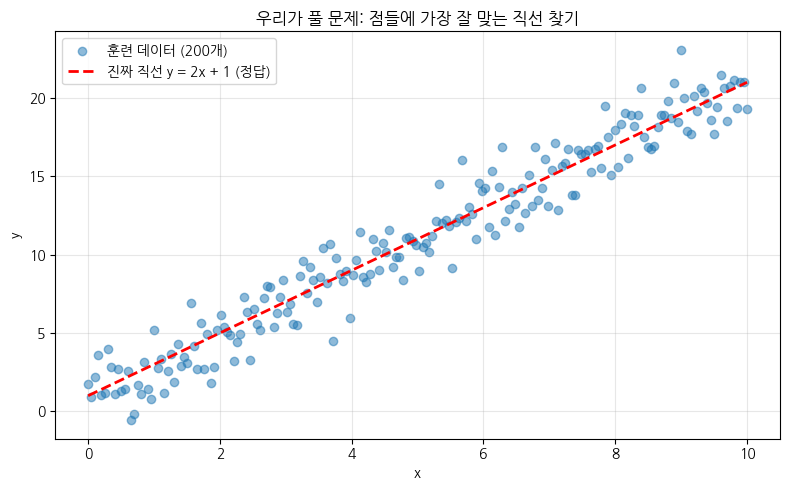

데이터 개수: 200개
진짜 정답:    w = 2.0, b = 1.0  (모델은 모름)


In [5]:
# 📊 가짜 데이터 만들기: y = 2x + 1 + 약간의 노이즈
np.random.seed(42)
N = 200
X_data = np.linspace(0, 10, N)
y_data = 2 * X_data + 1 + np.random.randn(N) * 1.5

plt.figure(figsize=(8, 5))
plt.scatter(X_data, y_data, alpha=0.5, label='훈련 데이터 (200개)')
plt.plot(X_data, 2 * X_data + 1, 'r--', linewidth=2, label='진짜 직선 y = 2x + 1 (정답)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('우리가 풀 문제: 점들에 가장 잘 맞는 직선 찾기')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"데이터 개수: {N}개")
print(f"진짜 정답:    w = 2.0, b = 1.0  (모델은 모름)")

---

## ✏️ 연습 1: 손실함수(MSE)를 직접 만들어 보세요

손실(Loss)은 "모델 예측이 정답에서 얼마나 떨어졌나" 를 숫자로 만든 것입니다.
**MSE(평균제곱오차)** 라는 손실을 사용합니다 — 이름은 거창하지만 그냥 **"차이의 제곱의 평균"** 입니다.

### 📝 만들어야 할 함수
```python
compute_loss(X, y, w, b)
# 입력: X(특성 배열), y(정답 배열), w(기울기), b(절편)
# 출력: 평균제곱오차 1개 숫자
```

### 💡 힌트 3단계로 생각하기

1️⃣ **예측값 만들기**: $\hat{y} = w \cdot x + b$
   - 넘파이 연산: `pred = w * X + b`

2️⃣ **차이의 제곱 계산**: $(\hat{y} - y)^2$
   - 넘파이 연산: `(pred - y) ** 2`

3️⃣ **평균 내기**: 모든 값을 더해서 데이터 개수로 나누기
   - 넘파이 연산: `np.mean(...)`

> 💡 위 세 줄을 합치면 단 한 줄 또는 두 줄로 만들 수 있어요!

In [6]:
# ✏️ 빈칸(...)을 채워서 함수를 완성하세요!
def compute_loss(X, y, w, b):
    # TODO 1: 모델 예측값을 만드세요
    pred = w*X+b   # 👈 여기를 채우세요 (힌트: w * X + b)

    # TODO 2: 평균제곱오차를 반환하세요
    return np.mean((pred-y)**2)   # 👈 여기를 채우세요 (힌트: np.mean((pred - y) ** 2))

In [7]:
# 🧪 자가 검증: 함수가 잘 만들어졌는지 자동으로 확인합니다
test_X = np.array([1.0, 2.0, 3.0, 4.0])
test_y = np.array([3.0, 5.0, 7.0, 9.0])  # 진짜 정답: w=2, b=1

try:
    # 검증 1) w=2, b=1 (정답 위치) → 손실은 0이어야 함
    r1 = compute_loss(test_X, test_y, w=2.0, b=1.0)
    # 검증 2) w=0, b=0 (엉터리) → 손실 = mean([9, 25, 49, 81]) = 41
    r2 = compute_loss(test_X, test_y, w=0.0, b=0.0)

    if abs(r1 - 0.0) < 1e-6 and abs(r2 - 41.0) < 1e-6:
        print(f"✅ 정답입니다! (정답 위치 손실 {r1:.2f}, 엉터리 위치 손실 {r2:.2f})")
    else:
        print(f"❌ 다시 시도해보세요.")
        print(f"   기대값: 0.0, 41.0  /  내 결과: {r1}, {r2}")
except Exception as e:
    print(f"⚠️  에러 발생: {e}")
    print("   → 빈칸(...)을 아직 안 채웠거나, 코드에 문제가 있어요.")

✅ 정답입니다! (정답 위치 손실 0.00, 엉터리 위치 손실 41.00)


<details>
<summary>🔑 정답 보기 (충분히 시도해본 뒤 클릭)</summary>

```python
def compute_loss(X, y, w, b):
    pred = w * X + b
    return np.mean((pred - y) ** 2)
```

**해설**:
- `w * X + b`: 넘파이 배열에 곱셈/덧셈을 하면 **모든 원소에 한 번에** 적용됩니다
- `(pred - y) ** 2`: 각 원소마다 차이를 제곱합니다 (음수 부호 없애기 + 큰 오차에 더 큰 벌점)
- `np.mean(...)`: 모든 값의 평균 = MSE 한 숫자가 나옵니다

</details>

---

## ✏️ 연습 2: 기울기 함수를 직접 만들어 보세요

**기울기(gradient)** 는 "이 방향으로 가면 Loss가 늘어난다"를 알려주는 신호입니다.
반대 방향으로 가면 Loss가 줄어들겠죠 → 그게 학습의 핵심!

### 📝 만들어야 할 함수
```python
compute_gradient(X, y, w, b)
# 출력: (dw, db) — w와 b 각각의 기울기
```

### 📐 수학 결과 (미분은 이미 다 해뒀습니다!)

손실 $L = \frac{1}{N}\sum (wx + b - y)^2$ 를 미분하면:

$$\frac{\partial L}{\partial w} = \frac{2}{N}\sum (\hat{y} - y) \cdot x \qquad \frac{\partial L}{\partial b} = \frac{2}{N}\sum (\hat{y} - y)$$

복잡해 보여도, **넘파이로 쓰면 한 줄씩**이에요:

### 💡 힌트
1️⃣ **예측값**: 연습 1과 똑같이 `pred = w * X + b`

2️⃣ **w의 기울기 (dw)**: `2 * np.mean((pred - y) * X)`
   - "(예측-정답) × 입력" 의 평균에 2배

3️⃣ **b의 기울기 (db)**: `2 * np.mean(pred - y)`
   - "(예측-정답)" 의 평균에 2배 (X가 곱해지지 않음!)

In [8]:
# ✏️ 빈칸(...)을 채워서 함수를 완성하세요!
def compute_gradient(X, y, w, b):
    # TODO 1: 예측값 계산
    pred =  w * X + b   # 👈 (힌트: 연습 1과 같음)

    # TODO 2: w의 기울기 계산
    dw = 2 * np.mean((pred-y)*X)     # 👈 (힌트: 2 * np.mean((pred - y) * X))

    # TODO 3: b의 기울기 계산
    db = 2 * np.mean(pred-y)     # 👈 (힌트: 2 * np.mean(pred - y))

    return dw, db

In [9]:
# 🧪 자가 검증
test_X = np.array([1.0, 2.0, 3.0, 4.0])
test_y = np.array([3.0, 5.0, 7.0, 9.0])  # 정답 직선: y = 2x + 1

try:
    # 검증 1) 정답 위치(w=2, b=1)에서는 기울기가 0이어야 함
    dw1, db1 = compute_gradient(test_X, test_y, w=2.0, b=1.0)
    # 검증 2) 엉터리 위치(w=0, b=0)에서는 음수 방향(아래로 가야 함)
    dw2, db2 = compute_gradient(test_X, test_y, w=0.0, b=0.0)

    ok1 = abs(dw1) < 1e-6 and abs(db1) < 1e-6
    ok2 = dw2 < 0 and db2 < 0

    if ok1 and ok2:
        print(f"✅ 정답입니다!")
        print(f"   정답 위치: dw={dw1:.4f}, db={db1:.4f}  (둘 다 0에 가까움)")
        print(f"   엉터리 위치: dw={dw2:.2f}, db={db2:.2f}  (둘 다 음수 → w, b를 키워야 함)")
    else:
        print(f"❌ 다시 시도해보세요.")
        print(f"   정답위치 기댓값: dw=0, db=0  /  내 결과: dw={dw1}, db={db1}")
        print(f"   엉터리위치 기대: 둘 다 음수  /  내 결과: dw={dw2}, db={db2}")
except Exception as e:
    print(f"⚠️  에러 발생: {e}")

✅ 정답입니다!
   정답 위치: dw=0.0000, db=0.0000  (둘 다 0에 가까움)
   엉터리 위치: dw=-35.00, db=-12.00  (둘 다 음수 → w, b를 키워야 함)


<details>
<summary>🔑 정답 보기 (클릭)</summary>

```python
def compute_gradient(X, y, w, b):
    pred = w * X + b
    dw = 2 * np.mean((pred - y) * X)
    db = 2 * np.mean(pred - y)
    return dw, db
```

**해설**:
- `(pred - y)` 는 "내 예측이 정답보다 얼마나 큰가?" 입니다
- 양수면 → 예측이 너무 컸음 → w, b를 줄여야 함 → 기울기가 양수로 나옴
- 음수면 → 예측이 너무 작았음 → w, b를 늘려야 함 → 기울기가 음수로 나옴
- 그래서 **"기울기 반대 방향"** 으로 가면 손실이 줄어듭니다

</details>

### ✅ 정답 함수로 표준화

아래 셀은 **표준 정답 코드**입니다. 위에서 직접 못 풀었더라도 이 셀을 실행하면
함수가 깔끔하게 정의되어 다음 단계로 넘어갈 수 있습니다.

In [15]:
# ✅ 표준 정답 함수 (다음 진행을 위해 꼭 실행하세요)
def compute_loss(X, y, w, b):
    pred = w * X + b
    return np.mean((pred - y) ** 2)

def compute_gradient(X, y, w, b):
    pred = w * X + b
    dw = 2 * np.mean((pred - y) * X)
    db = 2 * np.mean(pred - y)
    return dw, db

# 동작 확인
print(f"w=0, b=0 일 때 손실: {compute_loss(X_data, y_data, 0, 0):.2f}")
print(f"w=2, b=1 일 때 손실: {compute_loss(X_data, y_data, 2, 1):.2f}  ← 정답에 가까울수록 작음!")

w=0, b=0 일 때 손실: 156.42
w=2, b=1 일 때 손실: 1.94  ← 정답에 가까울수록 작음!


## ⚙️ 세 가지 학습 알고리즘

세 방식의 차이는 단 한 줄! **"기울기를 계산할 때 데이터를 몇 개 보느냐"** 만 다릅니다.
**배치 GD**와 **SGD**는 먼저 보여드리고, 가장 중요한 **미니배치 GD**는 직접 만들어 봅시다.

In [16]:
# 🐢 1) 배치 경사하강법: 매번 전체 데이터 사용
def batch_gd(X, y, lr=0.01, epochs=50):
    w, b = 0.0, 0.0
    history = []
    for epoch in range(epochs):
        dw, db = compute_gradient(X, y, w, b)   # 전체 데이터로 기울기
        w -= lr * dw
        b -= lr * db
        history.append((w, b, compute_loss(X, y, w, b)))
    return history

# 🐇 2) 확률적 경사하강법(SGD): 매번 1개 데이터만 사용
def sgd(X, y, lr=0.01, epochs=50):
    w, b = 0.0, 0.0
    history = []
    n = len(X)
    for epoch in range(epochs):
        for i in np.random.permutation(n):       # 데이터 순서 섞기
            xi, yi = X[i:i+1], y[i:i+1]          # 딱 1개만!
            dw, db = compute_gradient(xi, yi, w, b)
            w -= lr * dw
            b -= lr * db
        history.append((w, b, compute_loss(X, y, w, b)))
    return history

print("✅ 배치 GD, SGD 함수 정의 완료!")

✅ 배치 GD, SGD 함수 정의 완료!


---

## ✏️ 연습 3: 미니배치 GD를 직접 만들어 보세요 (오늘의 핵심!)

위의 SGD 코드를 살짝만 바꾸면 미니배치 GD가 됩니다.
**"1개씩"을 "batch_size개씩"으로 바꾸는 것**이 전부예요!

### 🧩 알고리즘 의사코드 (한국어 버전)

```
반복: 에포크 epochs번
    1단계: 데이터 인덱스를 무작위로 섞는다 (np.random.permutation)
    2단계: 0부터 n까지 batch_size 간격으로 순회
        - 현재 위치부터 batch_size개의 데이터를 골라낸다
        - 이 미니배치로 기울기를 계산한다
        - w, b를 업데이트한다 (w -= lr * dw)
    3단계: 한 에포크 끝났으니 손실을 기록한다
```

### 💡 힌트

1️⃣ **인덱스 섞기**: `idx = np.random.permutation(n)` (n=데이터 개수)

2️⃣ **배치별 순회**: `for start in range(0, n, batch_size):`
   - start는 0, batch_size, 2*batch_size, ... 순으로 진행

3️⃣ **현재 배치 인덱스 추출**: `batch = idx[start:start + batch_size]`

4️⃣ **그 인덱스의 데이터 가져오기**: `xb, yb = X[batch], y[batch]`

5️⃣ **기울기 계산 후 업데이트**: SGD와 똑같은 방식!

In [10]:
# ✏️ 빈칸(...)을 채워서 미니배치 GD를 완성하세요!
def mini_batch_gd(X, y, lr=0.01, epochs=50, batch_size=20):
    w, b = 0.0, 0.0
    history = []
    n = len(X)

    for epoch in range(epochs):
        # TODO 1: 데이터 인덱스를 무작위로 섞으세요
        idx = np.random.permutation(n)   # 👈 (힌트: np.random.permutation(n))

        # 미니배치 단위로 순회
        for start in range(0, n, batch_size):
            # TODO 2: 현재 배치의 인덱스를 잘라내세요
            batch = idx[start:start + batch_size]   # 👈 (힌트: idx[start:start + batch_size])

            # TODO 3: 그 인덱스에 해당하는 X, y를 가져오세요
            xb = X[batch]      # 👈 (힌트: X[batch])
            yb = y[batch]      # 👈 (힌트: y[batch])

            # TODO 4: 미니배치로 기울기 계산
            dw, db = compute_gradient(xb, yb, w, b)  # 👈 (힌트: compute_gradient(xb, yb, w, b))

            # TODO 5: w, b 업데이트 (한 걸음 내딛기!)
            w -= lr * dw       # 👈 (힌트: w - lr * dw)
            b -= lr * db       # 👈 (힌트: b - lr * db)

        # 에포크 끝나고 손실 기록
        history.append((w, b, compute_loss(X, y, w, b)))

    return history

In [11]:
# 🧪 자가 검증: 학습 후 정답(w=2, b=1)에 가까이 가면 성공
np.random.seed(0)
try:
    test_hist = mini_batch_gd(X_data, y_data, lr=0.01, epochs=50, batch_size=20)
    w_f, b_f, loss_f = test_hist[-1]

    if abs(w_f - 2.0) < 0.3 and abs(b_f - 1.0) < 0.6 and loss_f < 5.0:
        print(f"✅ 정답입니다!")
        print(f"   학습 결과: w = {w_f:.3f}, b = {b_f:.3f}, 손실 = {loss_f:.4f}")
        print(f"   진짜 정답: w = 2.000, b = 1.000  →  거의 도달!")
    else:
        print(f"❌ 다시 시도해보세요.")
        print(f"   학습 결과: w = {w_f:.3f}, b = {b_f:.3f}, 손실 = {loss_f:.4f}")
        print(f"   기대: w≈2, b≈1, 손실 < 5")
except Exception as e:
    print(f"⚠️  에러 발생: {e}")
    print("   → 빈칸을 모두 채웠는지 확인하세요.")

✅ 정답입니다!
   학습 결과: w = 2.031, b = 0.733, 손실 = 1.9330
   진짜 정답: w = 2.000, b = 1.000  →  거의 도달!


<details>
<summary>🔑 정답 보기 (클릭)</summary>

```python
def mini_batch_gd(X, y, lr=0.01, epochs=50, batch_size=20):
    w, b = 0.0, 0.0
    history = []
    n = len(X)
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            xb, yb = X[batch], y[batch]
            dw, db = compute_gradient(xb, yb, w, b)
            w -= lr * dw
            b -= lr * db
        history.append((w, b, compute_loss(X, y, w, b)))
    return history
```

**🎉 축하합니다!**
이걸 만들 수 있다면 사실상 **모든 딥러닝 학습의 핵심 코드**를 이해한 것입니다.
PyTorch, TensorFlow가 내부에서 하는 일이 정확히 이거예요.

</details>

In [12]:
# ✅ 표준 정답 함수 (다음 진행을 위해 실행)
def mini_batch_gd(X, y, lr=0.01, epochs=50, batch_size=20):
    w, b = 0.0, 0.0
    history = []
    n = len(X)
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            xb, yb = X[batch], y[batch]
            dw, db = compute_gradient(xb, yb, w, b)
            w -= lr * dw
            b -= lr * db
        history.append((w, b, compute_loss(X, y, w, b)))
    return history

print("✅ 세 함수 모두 준비 완료! 이제 실험을 시작합니다.")

✅ 세 함수 모두 준비 완료! 이제 실험을 시작합니다.


In [17]:
# 🚀 세 가지 방식 모두 학습 시켜보기
np.random.seed(0); hist_batch = batch_gd(X_data, y_data, lr=0.01, epochs=50)
np.random.seed(0); hist_sgd   = sgd(X_data, y_data, lr=0.01, epochs=50)
np.random.seed(0); hist_mini  = mini_batch_gd(X_data, y_data, lr=0.01, epochs=50, batch_size=20)

print("=" * 55)
print(f"{'방식':<20} {'w':>8} {'b':>8} {'최종 Loss':>12}")
print("=" * 55)
for name, hist in [('🐢 배치 GD', hist_batch),
                   ('🐇 SGD', hist_sgd),
                   ('🚲 미니배치 GD', hist_mini)]:
    w, b, loss = hist[-1]
    print(f"{name:<20} {w:>8.3f} {b:>8.3f} {loss:>12.4f}")
print("=" * 55)
print("👉 정답은 w=2.0, b=1.0 이었습니다.")

방식                          w        b      최종 Loss
🐢 배치 GD                 2.087    0.416       1.9619
🐇 SGD                   2.069    0.879       2.0213
🚲 미니배치 GD               2.031    0.733       1.9330
👉 정답은 w=2.0, b=1.0 이었습니다.


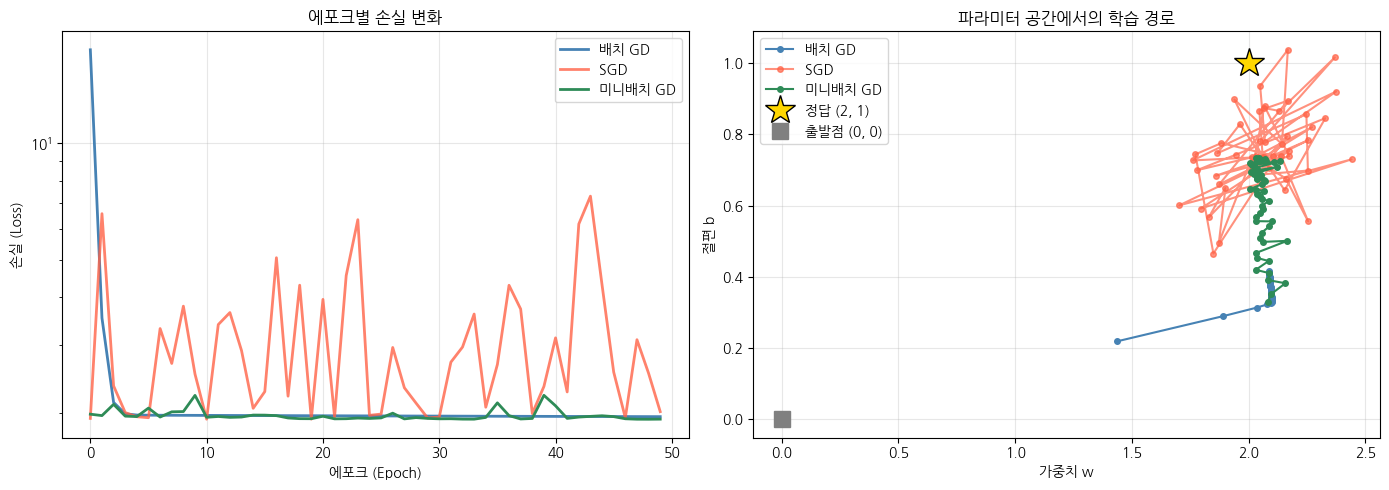

In [18]:
# 📉 학습 곡선 + 학습 경로 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

losses_batch = [h[2] for h in hist_batch]
losses_sgd   = [h[2] for h in hist_sgd]
losses_mini  = [h[2] for h in hist_mini]

axes[0].plot(losses_batch, label='배치 GD', color='steelblue', linewidth=2)
axes[0].plot(losses_sgd,   label='SGD', color='tomato', linewidth=2, alpha=0.8)
axes[0].plot(losses_mini,  label='미니배치 GD', color='seagreen', linewidth=2)
axes[0].set_xlabel('에포크 (Epoch)'); axes[0].set_ylabel('손실 (Loss)')
axes[0].set_title('에포크별 손실 변화'); axes[0].set_yscale('log')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([h[0] for h in hist_batch], [h[1] for h in hist_batch],
             'o-', label='배치 GD', color='steelblue', markersize=4)
axes[1].plot([h[0] for h in hist_sgd], [h[1] for h in hist_sgd],
             'o-', label='SGD', color='tomato', markersize=4, alpha=0.7)
axes[1].plot([h[0] for h in hist_mini], [h[1] for h in hist_mini],
             'o-', label='미니배치 GD', color='seagreen', markersize=4)
axes[1].plot(2, 1, '*', color='gold', markersize=22, markeredgecolor='black', label='정답 (2, 1)')
axes[1].plot(0, 0, 's', color='gray', markersize=12, label='출발점 (0, 0)')
axes[1].set_xlabel('가중치 w'); axes[1].set_ylabel('절편 b')
axes[1].set_title('파라미터 공간에서의 학습 경로')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 🔬 6. 실험: 배치 크기를 바꾸면 어떻게 될까?

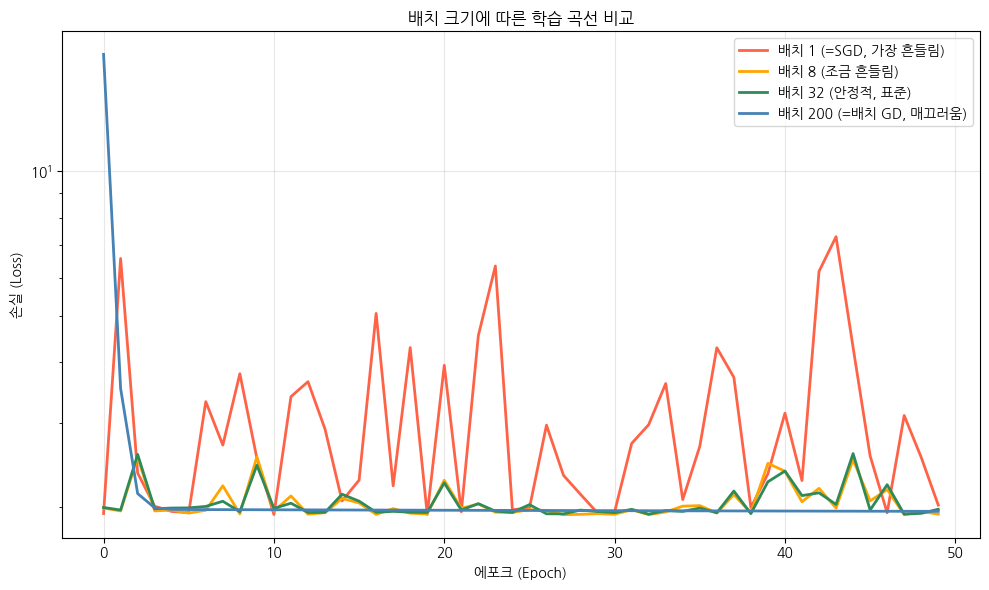

📌 배치 크기가 작을수록: 곡선이 들쭉날쭉
📌 배치 크기가 클수록:  곡선이 매끄러움
📌 실무에서는 보통 32, 64, 128을 자주 씁니다


In [19]:
# 배치 크기를 바꿔가며 학습 곡선 비교
batch_sizes = [1, 8, 32, 200]
results = {}

for bs in batch_sizes:
    np.random.seed(0)
    hist = mini_batch_gd(X_data, y_data, lr=0.01, epochs=50, batch_size=bs)
    results[bs] = [h[2] for h in hist]

plt.figure(figsize=(10, 6))
colors = ['tomato', 'orange', 'seagreen', 'steelblue']
labels = ['배치 1 (=SGD, 가장 흔들림)',
          '배치 8 (조금 흔들림)',
          '배치 32 (안정적, 표준)',
          '배치 200 (=배치 GD, 매끄러움)']
for bs, color, label in zip(batch_sizes, colors, labels):
    plt.plot(results[bs], label=label, color=color, linewidth=2)

plt.xlabel('에포크 (Epoch)'); plt.ylabel('손실 (Loss)')
plt.title('배치 크기에 따른 학습 곡선 비교'); plt.yscale('log')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("📌 배치 크기가 작을수록: 곡선이 들쭉날쭉")
print("📌 배치 크기가 클수록:  곡선이 매끄러움")
print("📌 실무에서는 보통 32, 64, 128을 자주 씁니다")

## 🧪 7. 직접 해보기 (자유 도전 과제)

아래 코드를 수정해보면서 어떻게 달라지는지 관찰해 보세요!

- `lr=0.001` (매우 작게) → 너무 천천히 내려옴
- `lr=0.05` (적당) → 적당히 내려옴
- `lr=0.5` (너무 크게) → 발산할 수도 있음 (Loss가 커짐!)

⚙️  설정:    학습률=0.01, 배치크기=8, 에포크=50
🎯 결과:    w = 2.049,  b = 0.751,  최종 Loss = 1.9360
📌 정답:    w = 2.000,  b = 1.000


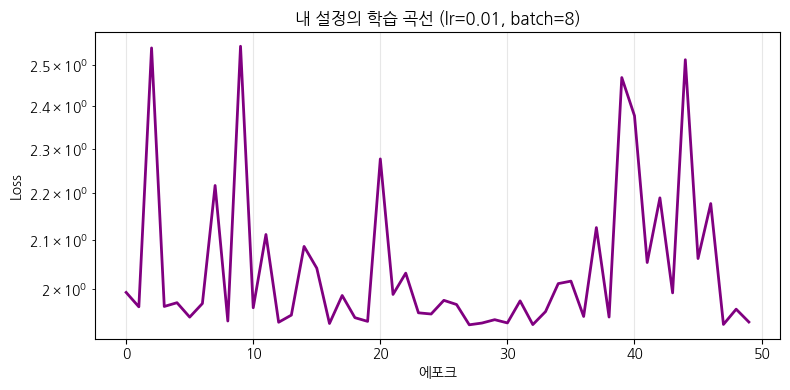

In [29]:
# 🧪 자유롭게 숫자를 바꿔가며 실행해 보세요!
my_lr = 0.01           # 👈 바꿔보세요 (예: 0.001, 0.05, 0.5)
my_batch_size = 8     # 👈 바꿔보세요 (예: 1, 4, 32, 200)
my_epochs = 50         # 👈 바꿔보세요 (예: 10, 100)

np.random.seed(0)
my_hist = mini_batch_gd(X_data, y_data, lr=my_lr, epochs=my_epochs,
                        batch_size=my_batch_size)
w_f, b_f, loss_f = my_hist[-1]

print(f"⚙️  설정:    학습률={my_lr}, 배치크기={my_batch_size}, 에포크={my_epochs}")
print(f"🎯 결과:    w = {w_f:.3f},  b = {b_f:.3f},  최종 Loss = {loss_f:.4f}")
print(f"📌 정답:    w = 2.000,  b = 1.000")

plt.figure(figsize=(8, 4))
plt.plot([h[2] for h in my_hist], color='purple', linewidth=2)
plt.title(f'내 설정의 학습 곡선 (lr={my_lr}, batch={my_batch_size})')
plt.xlabel('에포크'); plt.ylabel('Loss'); plt.yscale('log')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 🎓 8. 한 장으로 정리

### ✨ 오늘 직접 만든 것 3가지

1. ✏️ **손실함수 (compute_loss)** — 모델이 얼마나 틀렸는지 측정
2. ✏️ **기울기 함수 (compute_gradient)** — 어느 방향으로 가야 하는지 알려줌
3. ✏️ **미니배치 GD (mini_batch_gd)** — 데이터를 묶음으로 잘라 한 걸음씩 학습

### 🗝️ 자주 듣게 될 용어 마지막 정리

| 용어 | 뜻 | 비유 |
|---|---|---|
| **에포크 (Epoch)** | 전체 데이터를 한 바퀴 다 쓴 것 | 책 한 권 처음부터 끝까지 읽기 |
| **배치 (Batch)** | 한 번에 묶어서 처리하는 데이터 묶음 | 한 챕터 |
| **반복 (Iteration)** | 가중치를 1번 업데이트한 것 | 챕터 하나 읽고 정리하기 |
| **학습률 (Learning Rate)** | 한 걸음의 보폭 | 보폭이 너무 크면 골짜기를 지나쳐버림 |
| **배치 크기 (Batch Size)** | 묶음에 들어가는 데이터 개수 | 한 챕터의 페이지 수 |

### 💪 다음에 배울 만한 것

- **모멘텀(Momentum)**: 관성 붙여서 더 빨리 내려가기
- **Adam, RMSprop**: 발걸음을 알아서 조절하는 똑똑한 옵티마이저
- **학습률 스케줄링**: 처음엔 큰 보폭, 나중엔 작은 보폭

---

> 🎉 **수고하셨습니다!**
> 빈칸 3개를 모두 직접 채워서 작동시켰다면, 이제 PyTorch나 TensorFlow를 써도
> 그 안에서 무슨 일이 벌어지는지 머릿속에 그림이 그려질 거예요. 그게 진짜 목표였습니다.